# Multiple Linear Regression — Compact Notebook

This notebook implements a minimal, step-by-step Multiple Linear Regression example.

**For comprehensive explanations, theory, and detailed examples**, see:
**[`../teaching/02_multiple_linear_regression.md`](../teaching/02_multiple_linear_regression.md)**

## Quick Steps Overview:

- **Step 1** — Import libraries & load data  
- **Step 2** — Read data and choose features & target  
- **Step 3** — Exploratory Data Analysis (EDA)  
- **Step 4** — Data cleaning: missing values, encoding, feature engineering  
- **Step 5** — Encode categorical variables (One-Hot Encoding)
- **Step 6** — Split data (Train / Test) and visualize split  
- **Step 7** — Train the model (Multiple Linear Regression)  
- **Step 8** — Make predictions and compare X_test vs y_test  
- **Step 9** — Evaluate performance (R², MAE, MSE)  
- **Step 10** — Visualize results and business insights


---

## Step 1 — Import libraries & load data

In [20]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

Libraries imported successfully!
NumPy version: 2.2.3
Pandas version: 2.2.3


## Step 2 — Read data and choose features & target

In [22]:
# Load the dataset
dataset = pd.read_csv('../data/startups_data.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", dataset.shape)
print("\nFirst 5 rows:")
print(dataset.head())

print("\nColumn names:")
print(dataset.columns.tolist())

print("\nDataset info:")
print(dataset.info())

# Define features and target
X = dataset.iloc[:, :-1].values  # All columns except last (features)
y = dataset.iloc[:, -1].values   # Last column (target: Profit)

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFeature columns:", dataset.columns[:-1].tolist())
print("Target column:", dataset.columns[-1])

Dataset loaded successfully!
Dataset shape: (50, 5)

First 5 rows:
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

Column names:
['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     flo

## Step 3 — Exploratory Data Analysis (EDA)

In [23]:
# Basic statistics
print("Dataset Description:")
print(dataset.describe())

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nUnique values in State column:")
print(dataset['State'].value_counts())

Dataset Description:
           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   90138.902500
50%     73051.080000   122699.795000    212716.240000  107978.190000
75%    101602.800000   144842.180000    299469.085000  139765.977500
max    165349.200000   182645.560000    471784.100000  192261.830000

Missing values:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Data types:
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

Unique values in State column:
State
New York      17
Califo

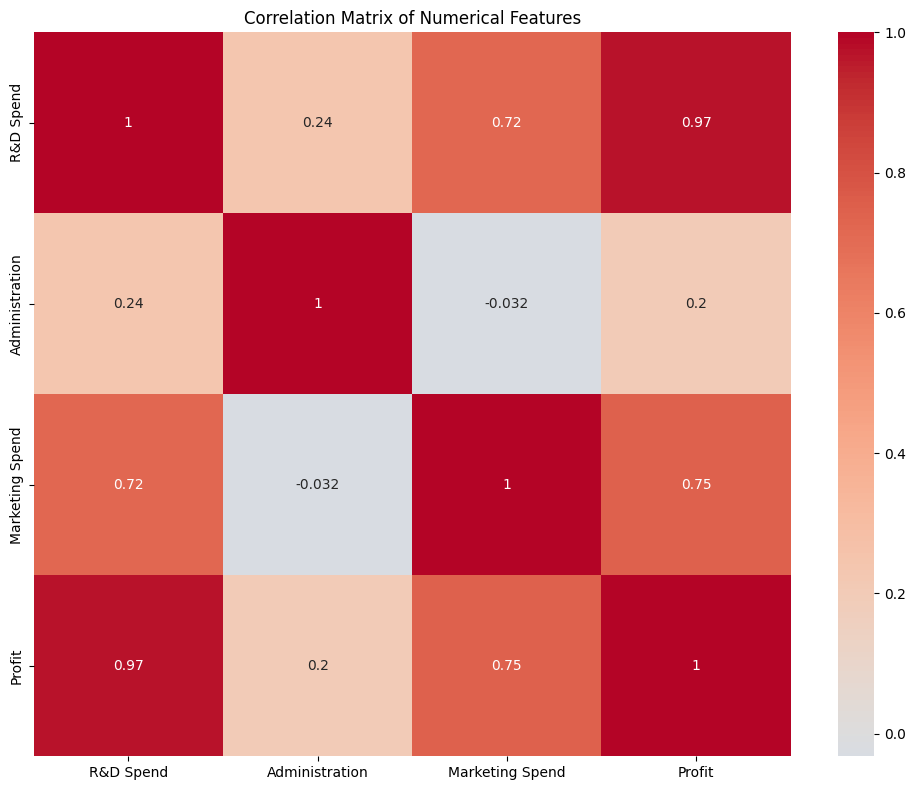

<Figure size 1200x800 with 0 Axes>

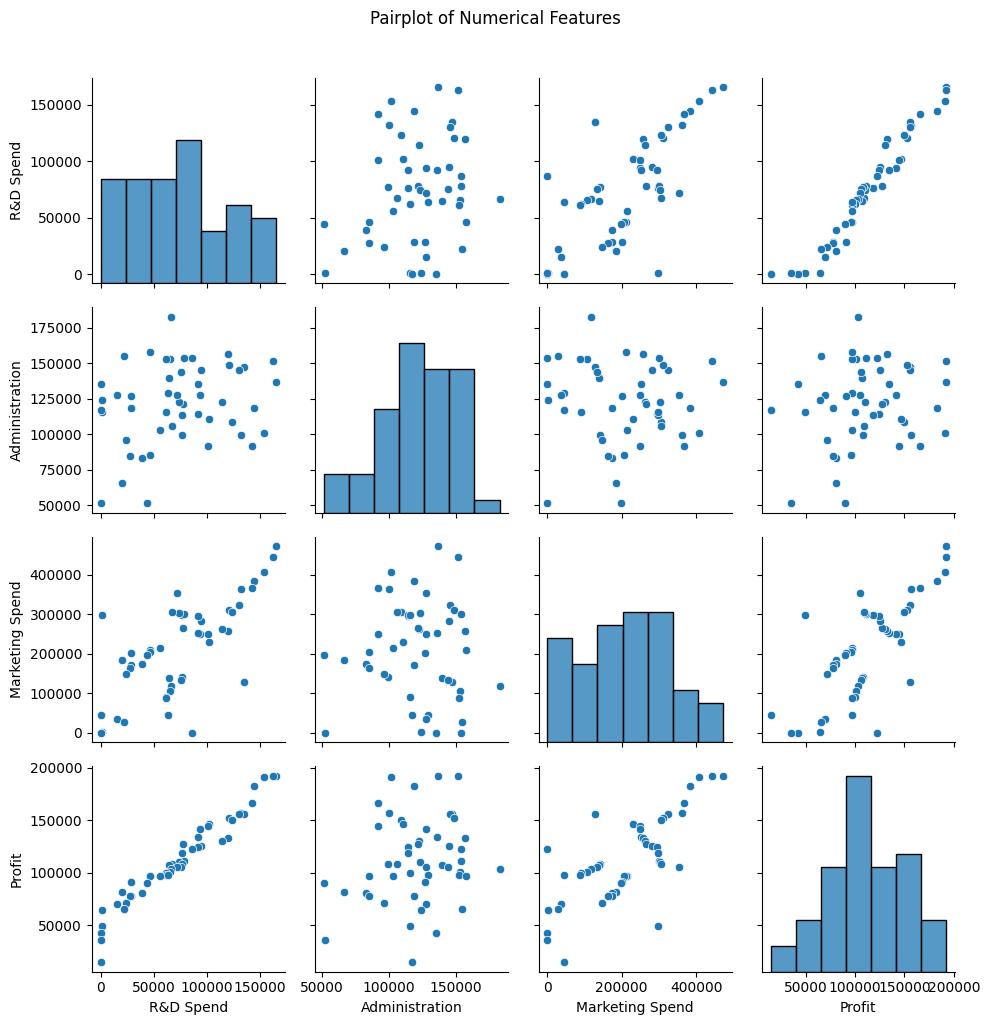

In [25]:
# Visualize correlations (numerical columns only)
plt.figure(figsize=(10, 8))
numerical_data = dataset.select_dtypes(include=[np.number])
correlation_matrix = numerical_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

# Pairplot for numerical features
plt.figure(figsize=(12, 8))
sns.pairplot(numerical_data)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — Data cleaning: missing values, encoding, feature engineering

In [26]:
# Check for missing values
print("Missing values per column:")
print(dataset.isnull().sum())

# Check data types
print("\nData types:")
print(dataset.dtypes)

# Identify categorical and numerical columns
categorical_columns = dataset.select_dtypes(include=['object']).columns.tolist()
numerical_columns = dataset.select_dtypes(include=[np.number]).columns.tolist()

print("\nCategorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

# Display first few rows to understand the data structure
print("\nFirst 5 rows:")
print(dataset.head())

# Summary statistics for numerical columns
print("\nSummary statistics for numerical features:")
print(dataset[numerical_columns].describe())

Missing values per column:
R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Data types:
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

Categorical columns: ['State']
Numerical columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']

First 5 rows:
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

Summary statistics for numerical features:
           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000   

## Step 5 — Encode categorical variables (One-Hot Encoding)

In [27]:
# Import encoding libraries
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Apply One-Hot Encoding to categorical variables
# We need to encode the 'State' column (which is in column index 3)

# Create column transformer for one-hot encoding
ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [3])  # Apply OneHotEncoder to column 3 (State)
    ], 
    remainder='passthrough'  # Keep other columns as they are
)

# Apply the transformation
X = ct.fit_transform(X)

print("Features after One-Hot Encoding:")
print("Shape:", X.shape)
print("\nFirst 5 rows:")
print(X[:5])

# Note: After one-hot encoding, we typically need to avoid the dummy variable trap
# by dropping one of the encoded columns. We'll handle this by removing the first column.
X = X[:, 1:]

print("\nAfter avoiding dummy variable trap:")
print("Shape:", X.shape)
print("\nFirst 5 rows:")
print(X[:5])

Features after One-Hot Encoding:
Shape: (50, 6)

First 5 rows:
[[0.0 0.0 1.0 165349.2 136897.8 471784.1]
 [1.0 0.0 0.0 162597.7 151377.59 443898.53]
 [0.0 1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 0.0 1.0 144372.41 118671.85 383199.62]
 [0.0 1.0 0.0 142107.34 91391.77 366168.42]]

After avoiding dummy variable trap:
Shape: (50, 5)

First 5 rows:
[[0.0 1.0 165349.2 136897.8 471784.1]
 [0.0 0.0 162597.7 151377.59 443898.53]
 [1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 142107.34 91391.77 366168.42]]


## Step 6 — Split data (Train / Test) and visualize split

In [28]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Data split successfully!")
print("Training set - Features:", X_train.shape, "Target:", y_train.shape)
print("Testing set - Features:", X_test.shape, "Target:", y_test.shape)



Data split successfully!
Training set - Features: (40, 5) Target: (40,)
Testing set - Features: (10, 5) Target: (10,)


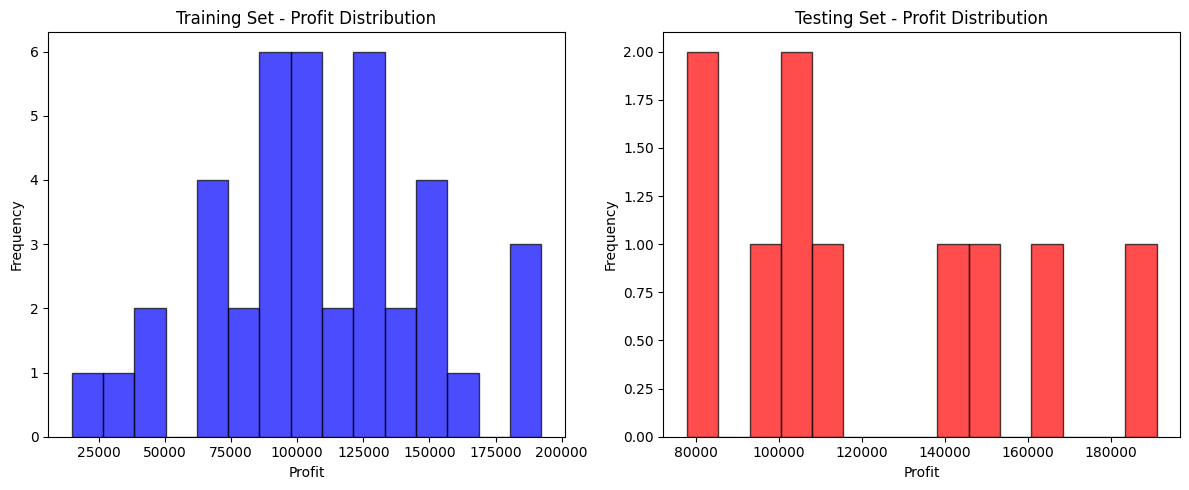

✅ Data split visualization completed!
Training set: 40 samples
Testing set: 10 samples


In [29]:
# Visualize the split distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set distribution
axes[0].hist(y_train, bins=15, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Training Set - Profit Distribution')
axes[0].set_xlabel('Profit')
axes[0].set_ylabel('Frequency')

# Testing set distribution
axes[1].hist(y_test, bins=15, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Testing Set - Profit Distribution')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("✅ Data split visualization completed!")
print(f"Training set: {len(y_train)} samples")
print(f"Testing set: {len(y_test)} samples")

## Step 7 — Train the model (Multiple Linear Regression)

In [30]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression

# Create and train the Multiple Linear Regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")
print("\nModel coefficients:")
print("Intercept (b0):", regressor.intercept_)
print("Coefficients (b1, b2, ...):", regressor.coef_)

# Display the linear equation
print("\nLinear Equation:")
equation = f"y = {regressor.intercept_:.2f}"
for i, coef in enumerate(regressor.coef_):
    equation += f" + ({coef:.2f}) * x{i+1}"
print(equation)

Multiple Linear Regression model trained successfully!

Model coefficients:
Intercept (b0): 42554.16761776614
Coefficients (b1, b2, ...): [-9.59284160e+02  6.99369053e+02  7.73467193e-01  3.28845975e-02
  3.66100259e-02]

Linear Equation:
y = 42554.17 + (-959.28) * x1 + (699.37) * x2 + (0.77) * x3 + (0.03) * x4 + (0.04) * x5


## Step 8 — Make predictions and compare X_test vs y_test

In [31]:
# Make predictions on the test set
y_pred = regressor.predict(X_test)

print("Predictions made successfully!")
print("Number of predictions:", len(y_pred))

# Compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Difference': y_test - y_pred,
    'Absolute_Difference': np.abs(y_test - y_pred)
})

print("\nActual vs Predicted comparison:")
print(comparison_df)

# Display some statistics about predictions
print("\nPrediction Statistics:")
print("Mean Absolute Error in comparison:", comparison_df['Absolute_Difference'].mean())
print("Max difference:", comparison_df['Absolute_Difference'].max())
print("Min difference:", comparison_df['Absolute_Difference'].min())

Predictions made successfully!
Number of predictions: 10

Actual vs Predicted comparison:
      Actual      Predicted    Difference  Absolute_Difference
0  103282.38  103015.201598    267.178402           267.178402
1  144259.40  132582.277608  11677.122392         11677.122392
2  146121.95  132447.738452  13674.211548         13674.211548
3   77798.83   71976.098513   5822.731487          5822.731487
4  191050.39  178537.482211  12512.907789         12512.907789
5  105008.31  116161.242302 -11152.932302         11152.932302
6   81229.06   67851.692097  13377.367903         13377.367903
7   97483.56   98791.733747  -1308.173747          1308.173747
8  110352.25  113969.435330  -3617.185330          3617.185330
9  166187.94  167921.065696  -1733.125696          1733.125696

Prediction Statistics:
Mean Absolute Error in comparison: 7514.293659636894
Max difference: 13674.211548250372
Min difference: 267.1784020374471


## Step 9 — Evaluate performance (R², MAE, MSE)

In [32]:
# Import metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate performance metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== MODEL PERFORMANCE METRICS ===")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

print(f"\nR² Interpretation: {r2*100:.2f}% of the variance in profit is explained by our features")

# Training set performance for comparison
y_train_pred = regressor.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
print(f"\nTraining R² Score: {r2_train:.4f}")
print(f"Testing R² Score: {r2:.4f}")

if r2_train - r2 > 0.1:
    print("Warning: Possible overfitting detected (large gap between training and testing performance)")
else:
    print("Good: No significant overfitting detected")

=== MODEL PERFORMANCE METRICS ===
R² Score: 0.9347
Mean Absolute Error (MAE): 7514.29
Mean Squared Error (MSE): 83502864.03
Root Mean Squared Error (RMSE): 9137.99

R² Interpretation: 93.47% of the variance in profit is explained by our features

Training R² Score: 0.9502
Testing R² Score: 0.9347
Good: No significant overfitting detected


## Step 10 — Visualize results and business insights

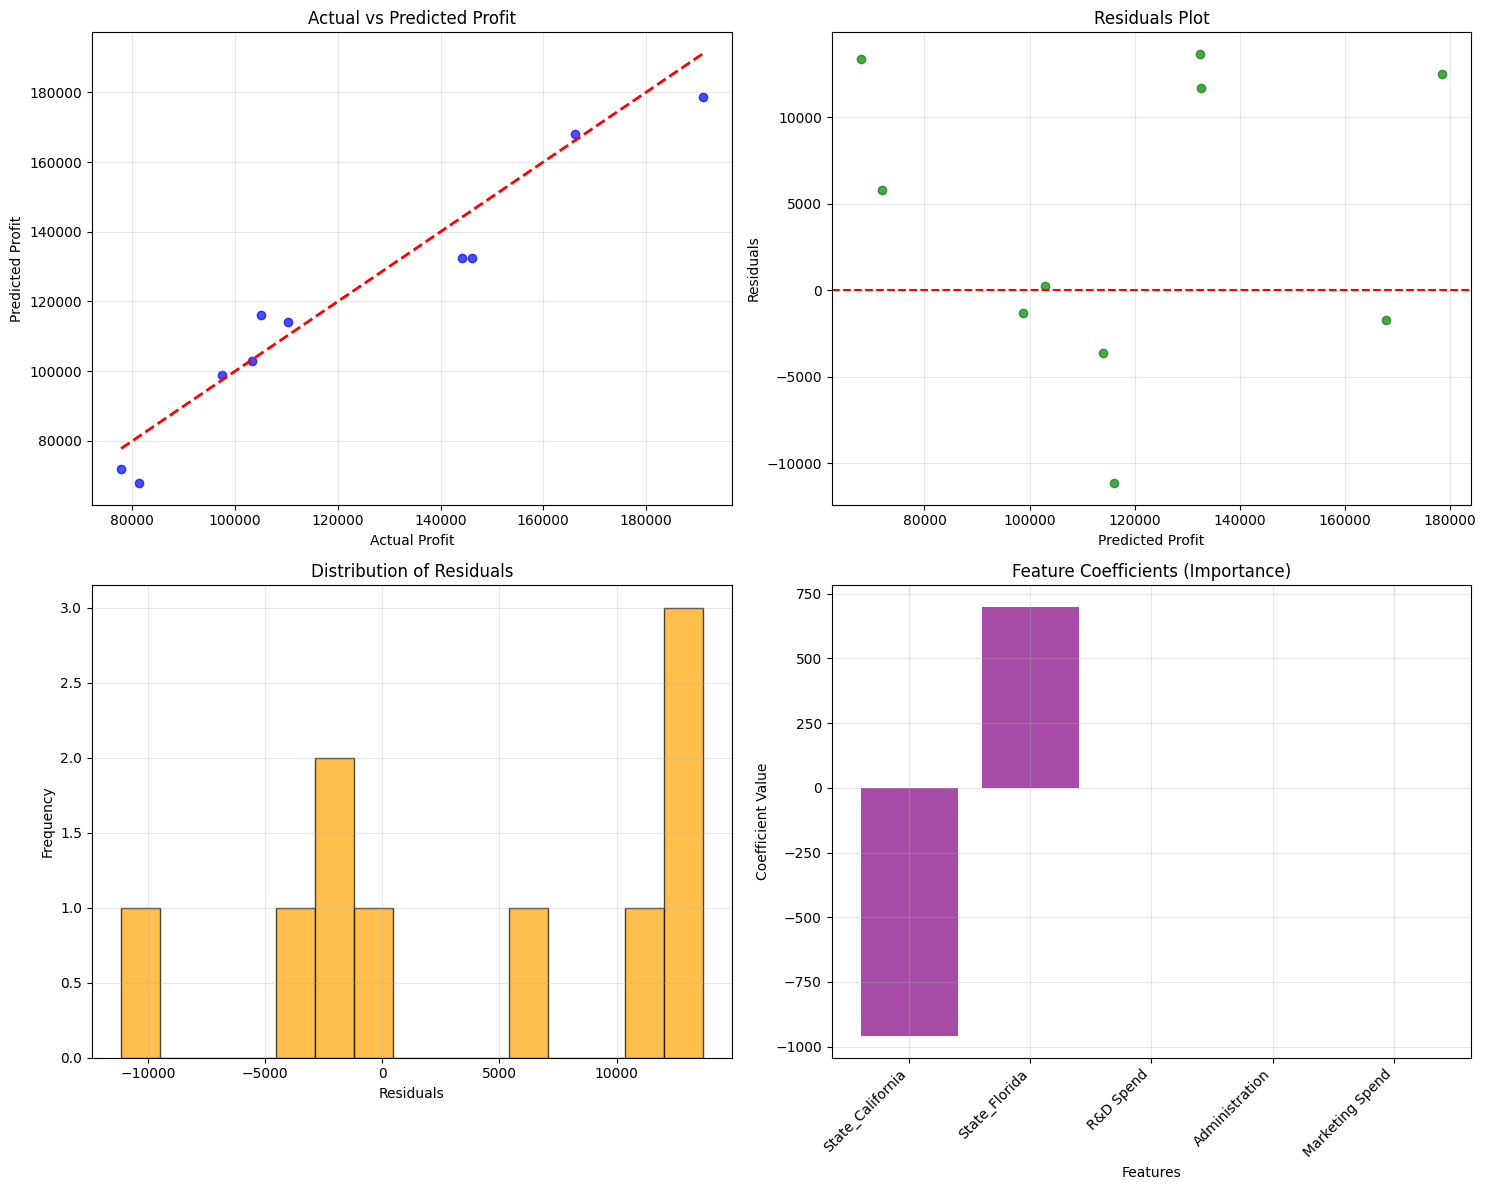

=== BUSINESS INSIGHTS ===
1. R&D Spend coefficient: 0.77
   - Every $1 increase in R&D spending increases profit by $0.77
2. Marketing Spend coefficient: 0.04
   - Every $1 increase in Marketing spending increases profit by $0.04
3. Administration coefficient: 0.03
   - Every $1 increase in Administration spending changes profit by $0.03

4. Most influential feature: State_California
   - Has the highest absolute coefficient value: 959.28


In [33]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Actual vs Predicted scatter plot
axes[0, 0].scatter(y_test, y_pred, alpha=0.7, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Profit')
axes[0, 0].set_ylabel('Predicted Profit')
axes[0, 0].set_title('Actual vs Predicted Profit')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.7, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicted Profit')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution of residuals
axes[1, 0].hist(residuals, bins=15, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature importance (coefficients)
feature_names = ['State_California', 'State_Florida', 'R&D Spend', 'Administration', 'Marketing Spend']
coefficients = regressor.coef_
axes[1, 1].bar(range(len(coefficients)), coefficients, color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Features')
axes[1, 1].set_ylabel('Coefficient Value')
axes[1, 1].set_title('Feature Coefficients (Importance)')
axes[1, 1].set_xticks(range(len(feature_names)))
axes[1, 1].set_xticklabels(feature_names, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Business insights
print("=== BUSINESS INSIGHTS ===")
print(f"1. R&D Spend coefficient: {coefficients[2]:.2f}")
print("   - Every $1 increase in R&D spending increases profit by ${:.2f}".format(coefficients[2]))
print(f"2. Marketing Spend coefficient: {coefficients[4]:.2f}")
print("   - Every $1 increase in Marketing spending increases profit by ${:.2f}".format(coefficients[4]))
print(f"3. Administration coefficient: {coefficients[3]:.2f}")
print("   - Every $1 increase in Administration spending changes profit by ${:.2f}".format(coefficients[3]))

most_important_feature = feature_names[np.argmax(np.abs(coefficients))]
print(f"\n4. Most influential feature: {most_important_feature}")
print(f"   - Has the highest absolute coefficient value: {np.max(np.abs(coefficients)):.2f}")

In [34]:
# Additional analysis: Prediction confidence intervals and summary
print("=== FINAL SUMMARY ===")
print(f"Model Performance: R² = {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f"Average Prediction Error: ${mae:,.2f}")
print(f"Model Equation: Profit = {regressor.intercept_:.2f}", end="")
for i, coef in enumerate(regressor.coef_):
    print(f" + {coef:.2f}*X{i+1}", end="")
print()

# Show best and worst predictions
best_prediction = np.argmin(np.abs(y_test - y_pred))
worst_prediction = np.argmax(np.abs(y_test - y_pred))

print(f"\nBest Prediction:")
print(f"  Actual: ${y_test[best_prediction]:,.2f}, Predicted: ${y_pred[best_prediction]:,.2f}")
print(f"  Error: ${abs(y_test[best_prediction] - y_pred[best_prediction]):,.2f}")

print(f"\nWorst Prediction:")
print(f"  Actual: ${y_test[worst_prediction]:,.2f}, Predicted: ${y_pred[worst_prediction]:,.2f}")
print(f"  Error: ${abs(y_test[worst_prediction] - y_pred[worst_prediction]):,.2f}")

print(f"\nConclusion: This Multiple Linear Regression model explains {r2*100:.1f}% of profit variation")
print("and can be used for business decision-making with reasonable accuracy.")

=== FINAL SUMMARY ===
Model Performance: R² = 0.9347 (93.5% variance explained)
Average Prediction Error: $7,514.29
Model Equation: Profit = 42554.17 + -959.28*X1 + 699.37*X2 + 0.77*X3 + 0.03*X4 + 0.04*X5

Best Prediction:
  Actual: $103,282.38, Predicted: $103,015.20
  Error: $267.18

Worst Prediction:
  Actual: $146,121.95, Predicted: $132,447.74
  Error: $13,674.21

Conclusion: This Multiple Linear Regression model explains 93.5% of profit variation
and can be used for business decision-making with reasonable accuracy.
